<a href="https://colab.research.google.com/github/vivsingh119/agentic-ai-practise/blob/master/Feature_Engineering2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt
import seaborn as sns;

In [18]:
df_diabiteis=pd.read_csv('https://raw.githubusercontent.com/vivsingh119/agentic-ai-practise/refs/heads/master/diabetes.csv')
df_diabiteis

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [19]:
df_diabiteis.shape

(768, 9)

In [20]:
df_diabiteis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Error Detection**

In [22]:
df_diabiteis.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


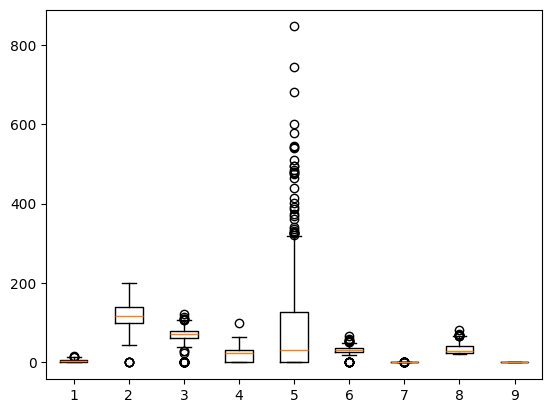

In [24]:
plt.boxplot(df_diabiteis)
plt.show()

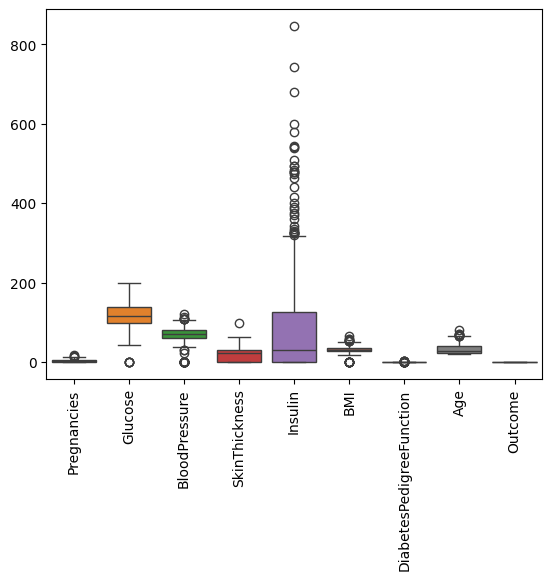

In [30]:
sns.boxplot(df_diabiteis)
plt.xticks(rotation=90)
plt.show()


In [33]:
# write a utlity logic to replace outlier from lower and upper limit
column=df_diabiteis.columns
column

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [41]:
## dont consider Outcome (this is dependent column)
column=column[:-1]
column

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [42]:
for c in column :
  #find skewness => +0 or +0 => normal Dis. +1 or -1 or greater than +1 or -1 then Skewed dist.
  skewness=df_diabiteis[c].skew().round()
  print(f"{c}: {skewness}")

Pregnancies: 1.0
Glucose: 0.0
BloodPressure: -2.0
SkinThickness: 0.0
Insulin: 2.0
BMI: -0.0
DiabetesPedigreeFunction: 2.0
Age: 1.0


In [55]:
for c in column:
  skewness=df_diabiteis[c].skew().round()
  if skewness==0:
    lower= df_diabiteis[c].mean()- 3*df_diabiteis[c].std()
    upper= df_diabiteis[c].mean()+ 3*df_diabiteis[c].std()
    #df_diabiteis[c]=df_diabiteis[c].map(lambda x: lower if(x<lower) else upper if(x>upper) else x)
  else:
     q1,q3=df_diabiteis[c].quantile([0.25,0.75])
     iqr=q3-q1
     lower=q1-1.5*iqr
     upper=q3+1.5*iqr
    # df_diabiteis[c]=df_diabiteis[c].map(lambda x: lower if(x<lower) else upper if(x>upper) else x)
  df_diabiteis[c]=df_diabiteis[c].clip(lower,upper)



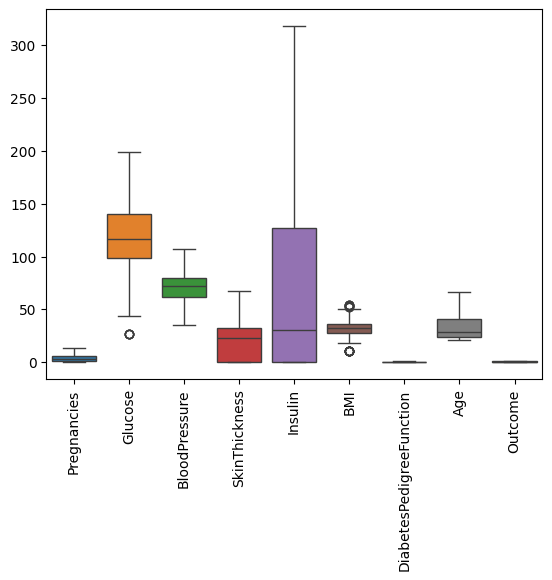

In [56]:
sns.boxplot(df_diabiteis)
plt.xticks(rotation=90)
plt.show()


In [58]:
df_diabiteis['Insulin'].skew().round()

np.float64(1.0)

In [60]:
abs(df_diabiteis['Insulin'].skew())

np.float64(1.1738981213083215)

In [61]:
df_diabiteis['Insulin'].skew()

np.float64(1.1738981213083215)

In [62]:
df_diabiteis["BloodPressure"].skew()

np.float64(-0.4060355281846069)

In [63]:
df_diabiteis["BloodPressure"].skew().round()

np.float64(-0.0)

In [64]:
abs(df_diabiteis["BloodPressure"].skew())

np.float64(0.4060355281846069)